## **CBDATSI Phase 2**

Phase 2 consists of three sections – (1) Data Modelling, (2) Statistical Inference, (3) Insights and Conclusions.

In [1]:
# Code explanation: Import the libraries needed to be used.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import os
import sys

sys.path.append(os.path.abspath(".."))

# Import preprocessing wrapper functions
from scripts.preprocessing import (
    run_preprocessing,
)

# Import clustering wrapper functions
from scripts.clustering import (
    select_features,
    standardize_features,
    calculate_vif,
    evaluate_kmeans_clusters,
    perform_kmeans,
    get_cluster_sizes,
    calculate_cluster_profiles,
    perform_shapiro_test,
    perform_kruskal_wallis,
    perform_dunn_test,
)

# sets the theme of the charts
plt.style.use('seaborn-v0_8-darkgrid')

%matplotlib inline

In [2]:
scommerce_df = run_preprocessing()

### [1] Data Modelling

#### **Feature Selection**
The six behavioral constructs were used as features for clustering because they represent the respondents' perceptions and behaviors associated with social commerce.



In [3]:
features = [
    "PU",
    "PEU",
    "FSC",
    "SP",
    "TP",
    "IB"
]

X = select_features(
    scommerce_df,
    features
)

 #### **Feature Standardization**
 The selected constructs were standardized to ensure equal contribution to the distance calculations used by K-Means.

In [4]:
X_scaled = standardize_features(
    X
)

#### **Variance Inflation Factor (VIF)**
VIF was computed to assess multicollinearity before clustering, with VIF > 5 indicating potentially problematic multicollinearity.

In [5]:
vif_data = calculate_vif(
    X_scaled,
    features
)

print(vif_data)

  Construct       VIF
0        PU  3.654939
1       PEU  3.515319
2       FSC  3.988501
3        SP  3.150629
4        TP  2.709242
5        IB  2.301402


VIF values ranged from 2.30 to 3.99, indicating no severe multicollinearity. Therefore, all constructs were retained.

#### **Clustering Algorithm**
K-Means was selected because of its computational efficiency and scalability for clustering the dataset.

#### **Selecting Optimal Number of k**
The optimal number of clusters was determined using the Elbow Method and Silhouette Analysis. The optimal value of k was selected by considering the results of both methods.

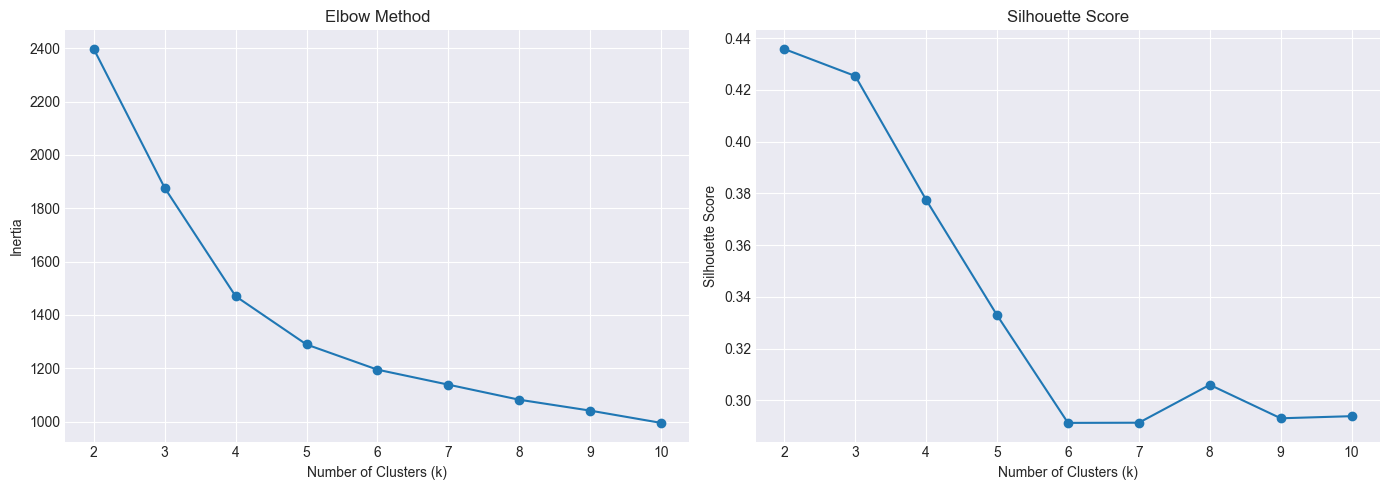

Inertia:
k=2: 2397.3951517810065
k=3: 1876.6780711816934
k=4: 1470.371175770248
k=5: 1289.3260086578698
k=6: 1194.8825839212625
k=7: 1138.661553747194
k=8: 1082.1602749640258
k=9: 1041.3118953265096
k=10: 995.2666652249214

Silhouette Scores:
k=2: 0.4357624529557227
k=3: 0.42533701123564177
k=4: 0.37747256266114426
k=5: 0.33290308059903284
k=6: 0.2913130488967038
k=7: 0.29138177791986325
k=8: 0.30602460012945765
k=9: 0.2930900543684983
k=10: 0.29391001252620486


In [6]:
k_values = range(2, 11)

inertia, silhouette_scores = evaluate_kmeans_clusters(
    X_scaled,
    k_values
)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Elbow Method
axes[0].plot(k_values, inertia, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].grid(True)

# Silhouette Score
axes[1].plot(k_values, silhouette_scores, marker="o")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("Inertia:")
for k, value in zip(range(2, 11), inertia):
    print(f"k={k}: {value}")

print("\nSilhouette Scores:")
for k, value in zip(range(2, 11), silhouette_scores):
    print(f"k={k}: {value}")

Based on the Elbow Method and Silhouette Analysis, k = 4 was selected as the optimal number of clusters. The elbow plot shows diminishing returns beyond k=4, while the silhouette score indicates that k=4 provides the best clustering solution.

#### **K-Means Clustering**

Now that the optimal number of clusters is determined, we can now start clustering.

In [7]:
kmeans, clusters = perform_kmeans(
    X_scaled
)

scommerce_df["Cluster"] = clusters

#### **Cluster Size**
Cluster sizes were examined to describe the distribution of respondents across the identified clusters.

In [8]:
cluster_sizes = get_cluster_sizes(
    clusters
)

cluster_sizes

0     97
1    258
2     20
3    382
Name: count, dtype: int64

Cluster 3 contained the largest number of respondents (382), followed by Cluster 1 (258), Cluster 0 (97), and Cluster 2 (20).

#### **Cluster Profiling**
Cluster profiles were generated by computing the mean values of the six behavioral constructs together with AUB for each cluster. These mean scores were used to characterize the identified user segments.

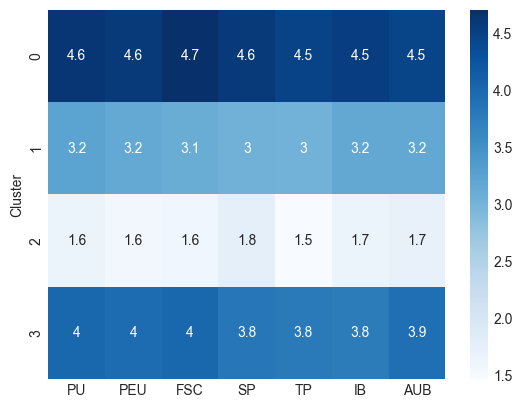

                  PU          PEU          FSC           SP           TP           IB          AUB
Cluster                                                                                           
0       4.6391752577 4.5841924399 4.7079037801 4.5773195876 4.4707903780 4.5257731959 4.4664948454
1       3.2451550388 3.1550387597 3.1020671835 3.0474806202 3.0348837209 3.1715116279 3.1715116279
2       1.6500000000 1.5666666667 1.5833333333 1.7750000000 1.4666666667 1.6625000000 1.7125000000
3       4.0215968586 3.9554973822 4.0200698080 3.8239528796 3.7870855148 3.7676701571 3.9201570681


In [9]:
cluster_profile = calculate_cluster_profiles(
    scommerce_df,
    features
)

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="Blues"
)

plt.show()

print(
    cluster_profile.to_string(
        float_format=lambda x: f"{x:.10f}"
    )
)

#### **Cluster 0: Highly Engaged Social Commerce Users**

AUB = 4.47, PU = 4.64, PEU = 4.58, FSC = 4.71, SP = 4.58, TP = 4.47, IB = 4.53

Cluster 0 consists of respondents who exhibit consistently high scores across all behavioral and perception constructs, with mean values above 4.4. Respondents in this cluster perceive social commerce platforms as useful and easy to use, are highly familiar with social commerce, trust the platforms, experience a strong sense of social presence, and actively interact with others. Consequently, they also demonstrate a high level of Actual Usage Behavior (AUB = 4.47). These respondents can be characterized as highly engaged and active social commerce users, indicating that positive perceptions across all measured constructs are associated with frequent use of social commerce platforms.

#### **Cluster 1: Moderate or Occasional Users**

AUB = 3.17, PU = 3.25, PEU = 3.16, FSC = 3.10, SP = 3.05, TP = 3.03, IB = 3.17

Cluster 1 represents respondents with generally neutral to moderately positive perceptions of social commerce. Their scores across all constructs are close to 3, suggesting that they neither strongly agree nor disagree with the statements measuring the constructs. This is reflected in their moderate Actual Usage Behavior (AUB = 3.17). These respondents may use social commerce occasionally but are not highly engaged. Improving their perceptions of the platform, particularly in areas such as trust and social interaction, may encourage greater adoption and more frequent usage.

#### **Cluster 2: Low Engagement Users**

AUB = 1.71, PU = 1.65, PEU = 1.57, FSC = 1.58, SP = 1.78, TP = 1.47, IB = 1.66

Cluster 2 contains the smallest number of respondents and exhibits the lowest mean scores across all constructs. Respondents in this cluster generally disagree that social commerce platforms are useful, easy to use, trustworthy, or socially engaging, resulting in the lowest level of Actual Usage Behavior (AUB = 1.71) among all clusters.

#### **Cluster 3: Regular Users with Positive Perceptions**

AUB = 3.92, PU = 4.02, PEU = 3.96, FSC = 4.02, SP = 3.82, TP = 3.79, IB = 3.77

Cluster 3 is the largest cluster in the dataset and represents respondents with generally positive perceptions of social commerce. While their scores are slightly lower than those of Cluster 0, they still report favorable levels of perceived usefulness, ease of use, familiarity, trust, social presence, and interaction behavior, which is reflected in their relatively high Actual Usage Behavior (AUB = 3.92). Compared with Cluster 1, respondents in this cluster consistently exhibit higher scores across all constructs, suggesting stronger confidence and engagement with social commerce rather than the moderate or uncertain perceptions observed in Cluster 1. However, compared to Cluster 0, they appear to be regular users rather than highly engaged users. Since this is the largest cluster, it may represent the typical Generation Z university student who has adopted social commerce and uses it regularly but whose engagement and confidence are not as strong as those observed in Cluster 0.

#### **Table Summary**

Below is the summary of Overall Profile, AUB, and Main Characteristics of the four clusters.

$$
\begin{array}{|l|l|c|l|}
\hline
\textbf{Cluster} & \textbf{Overall Profile} & \textbf{AUB} & \textbf{Main Characteristic} \\
\hline
0 & \text{Highly Engaged Users} & 4.47 & \text{Very high engagement across all constructs} \\
\hline
1 & \text{Moderate/Occasional Users} & 3.17 & \text{Neutral perceptions and moderate usage} \\
\hline
2 & \text{Low Engagement Users} & 1.71 & \text{Low perceptions and minimal usage} \\
\hline
3 & \text{Regular Users} & 3.92 & \text{Positive perceptions and regular usage} \\
\hline
\end{array}
$$

### [2] Statistical Inference

Since AUB was excluded during cluster formation, it was analyzed separately to determine whether actual usage behavior differs significantly across the identified clusters.

To determine whether AUB differs among the identified clusters, the following hypotheses are formulated.


$$
H_0:\ \mu_0 = \mu_1 = \mu_2 = \mu_3,\ \text{where the mean AUB is equal across all clusters.}
$$

$$
H_1:\ \exists\, i \ne j : \mu_i \ne \mu_j,\ \text{where at least one cluster has a different mean AUB.}
$$

#### **Assumption Checking**

Before performing One-Way ANOVA, its assumptions were evaluated. Independent observations and a continuous dependent variable were satisfied; therefore, only normality was assessed using the Shapiro-Wilk test. The hypotheses are defined as follows.

$H_0$: The AUB values within each cluster are normally distributed.

$H_1$: The AUB values within each cluster are not normally distributed.

In [10]:
shapiro_results = perform_shapiro_test(
    scommerce_df
)

for cluster, stat, p in shapiro_results:
    print(
        f"Cluster {cluster}: W={stat:.4f}, p={p:.4f}"
    )

Cluster 0: W=0.8871, p=0.0000
Cluster 1: W=0.8512, p=0.0000
Cluster 2: W=0.8787, p=0.0168
Cluster 3: W=0.8786, p=0.0000


Since all clusters yielded p < .05, the normality assumption was violated. Therefore, the Kruskal–Wallis H test was used instead of One-Way ANOVA, and the hypotheses were reformulated as follows.

### **The hypotheses for the Kruskal–Wallis H test are formulated as follows.**

$$
H_0:\ \text{The distribution of AUB is identical across all clusters.}
$$

$$
H_1:\ \text{At least one cluster has a different distribution of AUB.}
$$

The Kruskal–Wallis H test compares the distributions of groups using ranked observations and does not require the assumption of normality. Therefore, it is an appropriate non-parametric alternative to One-Way ANOVA for comparing AUB across clusters.

The assumptions of independent observations, independent groups, and an ordinal/continuous dependent variable were satisfied because each respondent belonged to only one cluster and AUB was treated as a continuous aggregated Likert-scale score. The test was therefore performed at $\alpha = 0.05$.

In [11]:
H, p = perform_kruskal_wallis(
    scommerce_df
)

print(f"H-statistic: {H}")
print(f"p-value: {p}")

H-statistic: 421.3159298947122
p-value: 5.341699041631374e-91


The Kruskal–Wallis H test revealed a statistically significant difference in the distribution of AUB across the four identified clusters (H = 421.32, p < .001). Therefore, the null hypothesis was rejected. Dunn's post hoc test with Bonferroni correction was subsequently performed to identify which cluster pairs differed significantly.

#### **Post Hoc Analysis**

Dunn's post hoc test with Bonferroni correction was performed to identify the significantly different cluster pairs. For each pairwise comparison, the hypotheses are defined as follows.

$H_0$: There is no statistically significant difference in the distribution of AUB between the two clusters being compared.

$H_1$: There is a statistically significant difference in the distribution of AUB between the two clusters being compared.

In [12]:
dunn = perform_dunn_test(
    scommerce_df
)

print(dunn.round(4).to_string())

     0       1       2    3
0  1.0  0.0000  0.0000  0.0
1  0.0  1.0000  0.0022  0.0
2  0.0  0.0022  1.0000  0.0
3  0.0  0.0000  0.0000  1.0


Dunn's post hoc test showed that all pairwise comparisons were statistically significant (*p* < .05). Therefore, the distribution of AUB differed significantly between every pair of identified clusters, indicating that each cluster represents a distinct pattern of Actual Usage Behavior.

### [3] Insights and Conclusions

#### **Insights**

After performing a clustering analysis, four distinct segments of Generation Z university students were identified based on their perceptions of social commerce: Highly Engaged Users, Regular Users with Positive Perceptions, Moderate or Occasional Users, and Low Engagement Users. The Elbow Method and Silhouette Analysis identified four clusters as the most suitable segmentation, indicating meaningful differences among respondents.

The cluster profiles reveal a clear relationship between users' perceptions of social commerce and their actual usage behavior. Respondents who reported higher levels of Perceived Usefulness (PU), Perceived Ease of Use (PEU), Familiarity with Social Commerce (FSC), Social Presence (SP), Trust in Platform (TP), and Interaction Behavior (IB) also exhibited higher Actual Usage Behavior (AUB). Conversely, respondents with consistently low perception scores demonstrated the lowest platform usage.

The largest cluster consisted of Regular Users with Positive Perceptions, suggesting that most respondents view social commerce favorably and engage with these platforms regularly, though not at the highest level. In contrast, Highly Engaged Users represented a smaller but strongly committed group with consistently high ratings across all behavioral constructs. Low Engagement Users formed the smallest cluster, indicating that only a limited portion of respondents maintain negative perceptions and low platform usage.

Statistical inference further validated the clustering results. The Shapiro-Wilk test assessed normality, and since the assumption was violated, the Kruskal-Wallis H test was used instead of One-Way ANOVA. The test found a statistically significant difference in Actual Usage Behavior across the four clusters (H = 421.32, p < .001). Dunn's post hoc analysis showed that every pair of clusters differed significantly, confirming that each segment represents a distinct level of social commerce engagement.

Overall, the findings suggest that positive perceptions of usefulness, ease of use, trust, familiarity, social presence, and interaction behavior are consistently associated with greater adoption and continued use of social commerce platforms among Generation Z university students.

#### **Conclusions**

This study successfully addressed the research question by identifying distinct behavioral segments among Generation Z university students through K-Means clustering. Four meaningful user profiles were discovered, each exhibiting different levels of perception toward social commerce and actual usage behavior.

The results demonstrate that students with more positive perceptions consistently exhibit higher platform usage, while less favorable perceptions are associated with lower engagement. Statistical testing confirmed that Actual Usage Behavior differs significantly across all clusters, reinforcing the validity and practical relevance of the segmentation.

These findings indicate that Generation Z users are not homogeneous. They differ in their attitudes, trust, familiarity, and engagement with social commerce platforms. Consequently, businesses and platform developers should adopt segment-specific strategies. Enhancing usability, trust, interactive features, and user familiarity may help encourage less engaged users to become more active while maintaining existing high-usage users.

Although the study provides meaningful insights into social commerce behavior among Generation Z university students, its findings are limited to the surveyed population and variables included in the dataset. The original dataset was collected through voluntary online and offline recruitment, with online recruitment relying on Facebook and Zalo. This may introduce self-selection bias and overrepresent students who are more active on social media or familiar with social commerce. Consequently, the identified segments may not fully represent the broader Generation Z student population. Future studies may employ more representative sampling, expand the respondent population, incorporate additional factors, and explore alternative clustering techniques to further validate these segments.